In [33]:
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Exploratory Data Analysis
TODO:
- Find and correct null or empty cells (in this case 0 in any numerical columns)
- Check correlation of features to model
- Features transformation, dimension reduction
- Split dataset to indivisual train/test datasets

In [ ]:
df = pd.read_csv('./data.csv')
df.head()
# df.info()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
# dropped columns: date, country, street as it doesnt have any predictive values
df.drop(columns=['date', 'country', 'street'], inplace=True)
# df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4600 non-null   float64
 1   bedrooms       4600 non-null   float64
 2   bathrooms      4600 non-null   float64
 3   sqft_living    4600 non-null   int64  
 4   sqft_lot       4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   waterfront     4600 non-null   int64  
 7   view           4600 non-null   int64  
 8   condition      4600 non-null   int64  
 9   sqft_above     4600 non-null   int64  
 10  sqft_basement  4600 non-null   int64  
 11  yr_built       4600 non-null   int64  
 12  yr_renovated   4600 non-null   int64  
 13  city           4600 non-null   object 
 14  statezip       4600 non-null   object 
dtypes: float64(4), int64(9), object(2)
memory usage: 539.2+ KB


Checking for missing values and outliers

In [ ]:
df[df['price'] == 0]
df['bedrooms'].value_counts()
df['bathrooms'].value_counts()
df['floors'].value_counts()

floors
1.0    2174
2.0    1811
1.5     444
3.0     128
2.5      41
3.5       2
Name: count, dtype: int64

In [22]:
# dropping invalid rows
df = df[df['price'] != 0]
df = df[df['bedrooms'] != 0]
df = df[df['bathrooms'] != 0]

#### Small features correlation section

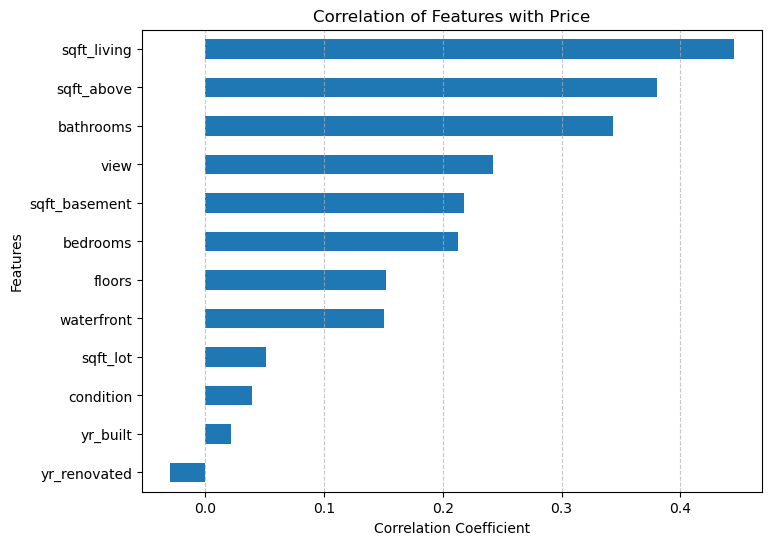

In [31]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(8, 6))
corr_matrix['price'].drop('price').sort_values(ascending=True).plot(kind='barh')
plt.title('Correlation of Features with Price')
plt.ylabel('Features')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x',linestyle='--', alpha=0.7)
plt.show()

Text(0.5, 1.0, 'Correlation Matrix of Features')

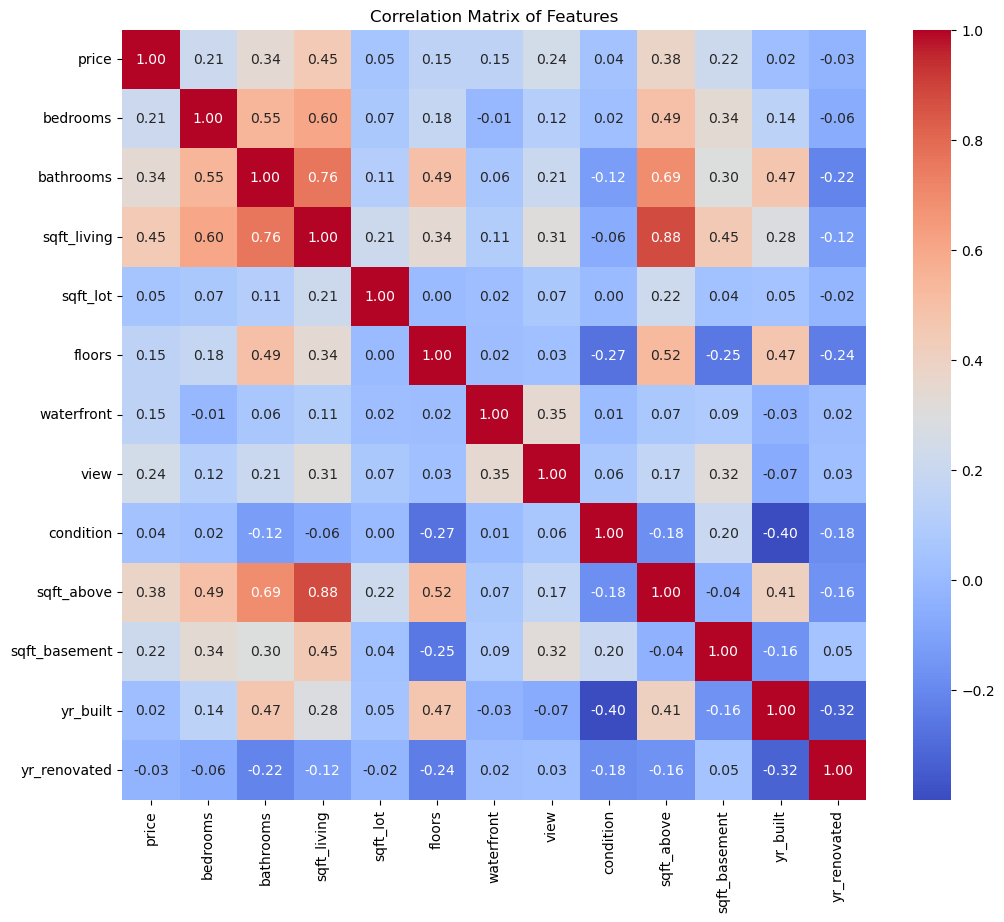

In [32]:
# all features correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Features')

#### Features transformation and generate train/test datasets

In [34]:
df = df.drop(columns=['statezip', 'sqft_above']) # use city for categorical features and sqft_living for main size feature
df_encoded = pd.get_dummies(df, columns=['city'], drop_first=True, dtype=int)
train_df, test_df = train_test_split(df_encoded, test_size=0.2, random_state=42)

train_df.to_csv('./train.csv', index=False)
test_df.to_csv('./test.csv', index=False)